In [2]:
%pip install tensorflow==2.15.0 -q
import tensorflow as tf

print(tf.__version__)

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Note: you may need to restart the kernel to use updated packages.

2.15.0


In [118]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN


In [3]:
# Load the dataset
max_features = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000,), Training labels shape: (25000,)
Testing data shape: (25000,), Testing labels shape: (25000,)


In [4]:
# Inspect a sample review and its label
sample_review = X_train[0]
sample_label = y_train[0]

print(f"Sample review (as integers): {sample_review}")
print(f"Sample label: {sample_label}")

Sample review (as integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


In [5]:
# Mapping of words index back to words
word_index = imdb.get_word_index()
# word_index
reverse_word_index = {value: key for key, value in word_index.items()}
reverse_word_index

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [6]:
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [7]:
max_len = 500
X_train = sequence.pad_sequences(X_train, maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)

In [8]:
X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [9]:
X_test[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

# RNN Model

In [10]:
# Train Simple RNN Model
model = Sequential()
model.add(Embedding(max_features, 128, input_length=max_len)) #Embedding layers
model.add(SimpleRNN(128, activation='relu')) #RNN layer
model.add(Dense(1, activation='sigmoid')) #Output layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build((None, max_len))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,025 (5.01 MB)

 Trainable params: 1,313,025 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Create an instance of EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
early_stopping

In [14]:
# Train the model with early stopping
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.6178 - loss: 0.9413 - val_accuracy: 0.6518 - val_loss: 0.5972
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7104 - loss: 0.5622 - val_accuracy: 0.7498 - val_loss: 0.5078
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8121 - loss: 0.4146 - val_accuracy: 0.7928 - val_loss: 0.4552
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.7760 - loss: 300.5345 - val_accuracy: 0.7034 - val_loss: 0.5440
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7595 - loss: 0.4889 - val_accuracy: 0.6916 - val_loss: 0.5808
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8083 - loss: 0.4097 - val_accuracy: 0.7052 - val_loss: 0.5862
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7836 - loss: 0.4336 - val_accuracy: 0.6142 - val_loss: 0.6593
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7142 - loss: 14.1380

In [16]:
y_pred = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


In [17]:
y_pred

array([[0.19761541],
       [0.9661532 ],
       [0.45413435],
       ...,
       [0.2813912 ],
       [0.09797715],
       [0.69846594]], dtype=float32)

In [18]:
y_train

array([1, 0, 0, ..., 0, 1, 0])

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:")
print(accuracy_score(y_test, (y_pred > 0.5).astype(int)))

print("Classification Report:")
print(classification_report(y_test, (y_pred > 0.5).astype(int)))

print("Confusion Matrix:")
print(confusion_matrix(y_test, (y_pred > 0.5).astype(int)))

Accuracy:
0.79608
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79     12500
           1       0.77      0.84      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

Confusion Matrix:
[[ 9404  3096]
 [ 2002 10498]]


# LSTM Model

In [21]:
from tensorflow.keras.layers import LSTM

In [22]:
# Train LSTM Model
lstm_model = Sequential()
lstm_model.add(Embedding(max_features, 128, input_length=max_len))
lstm_model.add(LSTM(128))
lstm_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
model.build(input_shape=(None, max_len))

In [27]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 500, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 128)              │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,235,141 (16.16 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,823,428 (10.77 MB)

In [28]:
lstm_model.fit(
    X_train, y_train,
    epochs=10, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7955 - loss: 0.4422 - val_accuracy: 0.8298 - val_loss: 0.3985
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8583 - loss: 0.3424 - val_accuracy: 0.7358 - val_loss: 0.5218
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8555 - loss: 0.3347 - val_accuracy: 0.8408 - val_loss: 0.4010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9214 - loss: 0.2014 - val_accuracy: 0.8696 - val_loss: 0.3495
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9512 - loss: 0.1368 - val_accuracy: 0.8538 - val_loss: 0.3925
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9423 - loss: 0.1456 - val_accuracy: 0.8136 - val_loss: 0.4891
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9523 - loss: 0.1279 - val_accuracy: 0.8448 - val_loss: 0.4624
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9696 - loss: 0.0868 - 

In [29]:
y_pred_lstm = lstm_model.predict(X_test)
y_pred_lstm

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


array([[0.36929375],
       [0.9966305 ],
       [0.14346945],
       ...,
       [0.07620335],
       [0.05989609],
       [0.7746724 ]], dtype=float32)

# BiLSTM Model

In [71]:
from tensorflow.keras.layers import Bidirectional

In [85]:
# Train BiLSTM Model
bilstm = Sequential()
bilstm.add(Embedding(max_features, 128, input_length=max_len))
bilstm.add(Bidirectional(LSTM(64, dropout=0.2)))
bilstm.add(Dense(1, activation='sigmoid'))

In [86]:
bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [87]:
bilstm.build(input_shape=(None, max_len))

In [88]:
bilstm.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [89]:
bilstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7780 - loss: 0.4606 - val_accuracy: 0.8368 - val_loss: 0.3710
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8730 - loss: 0.3087 - val_accuracy: 0.8084 - val_loss: 0.4168
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9080 - loss: 0.2340 - val_accuracy: 0.8696 - val_loss: 0.3156
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9373 - loss: 0.1725 - val_accuracy: 0.8678 - val_loss: 0.3743
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9515 - loss: 0.1367 - val_accuracy: 0.8546 - val_loss: 0.3955
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9614 - loss: 0.1062 - val_accuracy: 0.8580 - val_loss: 0.4345
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9682 - loss: 0.0899 - val_accuracy: 0.8666 - val_loss: 0.5076
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.9776 - loss: 0.0663 - 

# Models comparison

In [93]:
rnn_eval = model.evaluate(X_test, y_test)
lstm_eval = lstm_model.evaluate(X_test, y_test)
bilstm_eval = bilstm.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7961 - loss: 0.4467
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8670 - loss: 0.3547
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8690 - loss: 0.3211


# Accuracy and Loss

In [94]:
print("Simple RNN Model Evaluation: ")
print("Loss: ", rnn_eval[0])
print("Accuracy: ", rnn_eval[1]*100, "%")

print("\nLSTM Model Evaluation: ")
print("Loss: ", lstm_eval[0])
print("Accuracy: ", lstm_eval[1]*100, "%")

print("\nBiLSTM Model Evaluation: ")
print("Loss: ", bilstm_eval[0])
print("Accuracy: ", bilstm_eval[1]*100, "%")

Simple RNN Model Evaluation: 
Loss:  0.44667738676071167
Accuracy:  79.60799932479858 %

LSTM Model Evaluation: 
Loss:  0.35472992062568665
Accuracy:  86.69999837875366 %

BiLSTM Model Evaluation: 
Loss:  0.32109183073043823
Accuracy:  86.89600229263306 %


# Model Saved

In [98]:
model.save("simple_rnn_model.h5") #RNN Model

In [110]:
lstm_model.save("lstm_model.h5") #LSTM Model

In [111]:
bilstm.save("bilstm_model.h5") #BiLSTM Model

# Confusion Matrix

In [129]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rnn = (model.predict(X_test) > 0.5).astype(int)
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int)
y_pred_bilstm = (bilstm.predict(X_test) > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step


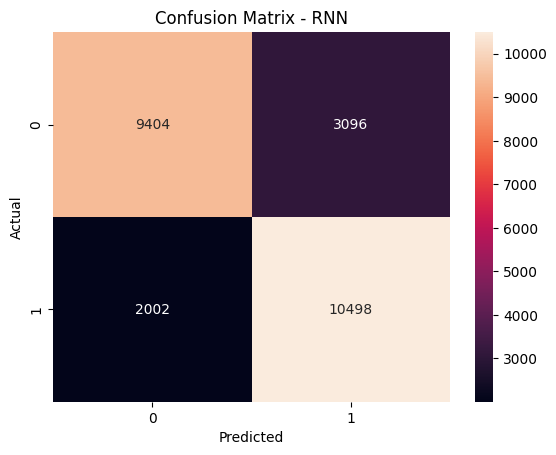

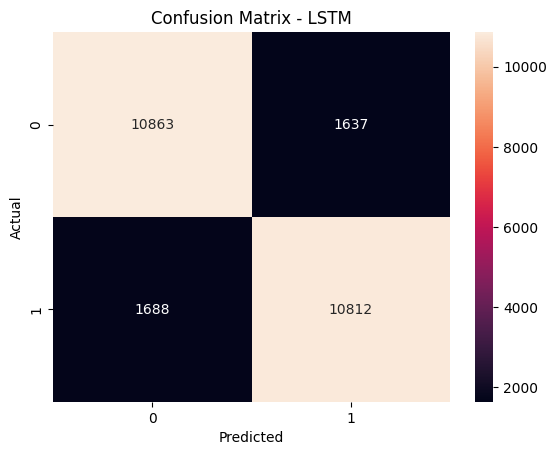

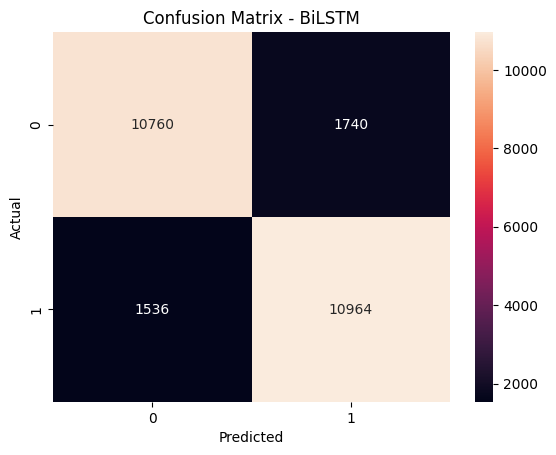

In [130]:
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)

#RNN Model
sns.heatmap(cm_rnn, annot=True, fmt='d')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#LSTM Model
sns.heatmap(cm_lstm, annot=True, fmt='d')
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#BiLSTM Model
sns.heatmap(cm_bilstm, annot=True, fmt='d')
plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [141]:
from sklearn.metrics import classification_report

print("Classification Report for RNN Model:")
print(classification_report(y_test, y_pred_rnn))

print("Classification Report for LSTM Model:")
print(classification_report(y_test, y_pred_lstm))

print("Classification Report for BiLSTM Model:")
print(classification_report(y_test, y_pred_bilstm))

Classification Report for RNN Model:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79     12500
           1       0.77      0.84      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

Classification Report for LSTM Model:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     12500
           1       0.87      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

Classification Report for BiLSTM Model:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     12500
           1       0.86      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg 